# TD 2: Tests non paramétriques de comparaison de plusieurs échantillons indépendants ou appariés

Matthias Grenié, Christelle Gonindard, Margaux Leroy, Vaea Tesan et François Bettega

<div class="alert alert-info" role="alert">

## Objectifs

* Être capable de comparer plusieurs échantillons avec des tests non paramétriques
* Identifier quand utiliser le test de Kruskal-Wallis
* Savoir interpréter le test de Kruskal-Wallis
* Identifier quand utiliser le test de Friedman
* Savoir interpréter le test de Friedman
</div>

---

## 1. Test de comparaison non paramétrique de plusieurs échantillons indépendants (Kruskal-Wallis)

### 1.1 Principe du test 

Le test de Kruskal-Wallis est la généralisation à K populations du test bilatéral de Mann-Whitney. Les données de tous les échantillons sont remplacées par leur rang: 

<img src="figures/Kruskall_Wallis2.jpg" />

Puis on est calculé : 

- $\bar{r}$, la moyenne globale des rangs (rang moyen tous échantillons confondus),
- $\bar{r_k}$, la moyenne des rangs pour les observations de l'échantillon $k$,
- $n$ la taille cumulée des effectifs de tous les échantillons.

<img src="figures/Kruskall_Wallis.jpg" />

Le principe de ce test peut être vu simplement de la manière suivante  : 

- s'il n'existe pas de différence entre les échantillons, la répartition des rangs entre les échantillons devrait être aléatoire ce qui impliquerait que tous les échantillons aient approximativement le même rang moyen soit $\bar{r}$ quel que soit $k$ ;
- ce qui a pour conséquence que $\bar{r_k}-\bar{r}$ devrait être proche de 0 pour chaque échantillon ;
- en conclusion, si l'on somme ces différences ($\bar{r_k}-\bar{r}$) pour tous les échantillons, cette somme devrait être proche de 0,
- si ce n'est pas le cas on peut en déduire la différence d'au moins un échantillon par rapport aux autres.

Pour plus de détails, voir le cours. 

### 1.2 Exemple : Comparaison de l’efficacité de 4 traitements

Différents traitements pour les boutons de fièvre, dont un placebo (**A**), ont été assignés au
hasard à 20 patients. Les données ci-dessous montrent, pour chaque traitement, le nombre de
jours jusqu’à guérison complète.

Les données sont contenues dans le fichier *`data_bouton_fievre.txt`* qui est dans le dossier *`data/`* (chemin d'accès relatif total `data/data_bouton_fievre.txt`).

**Question de l'étude : Les temps de guériso sont-ils différents selon les traitements utilisés ?**  
(c'est-à-dire, est-ce que les traitements administrés sont différents du placebo ?)

#### Lecture et description des données

1. Lire les données

In [2]:
fievre = read.table("data/data_bouton_fievre.txt", header = TRUE)

2. Présentation des données et description

In [8]:
head(fievre)
summary(fievre)
length(fievre$jour)

,jour,traitement
,<int>,<chr>
1,6,A
2,8,A
3,7,A
4,7,A
5,4,A
6,4,B


      jour       traitement       
 Min.   :3.00   Length:20         
 1st Qu.:4.00   Class :character  
 Median :5.00   Mode  :character  
 Mean   :5.15                     
 3rd Qu.:6.00                     
 Max.   :8.00                     

[1] 20

Combien y a-t-il de patients assignés aux différents traitement ? Calculez-le avec R.

*Indice : vous pouvez le savoir en filtrant les lignes pour chaque traitement ou bien en calculant une table de contingence (=effectifs de chaque traitement) de la variable `traitement`*

In [9]:
# Table de contingence
table(fievre$traitement)

# Filtre et compte
traitementA = fievre[fievre$traitement == "A", ]
length(traitementA$jour)

traitementB = fievre[fievre$traitement == "B", ]
length(traitementB$jour)

traitementC = fievre[fievre$traitement == "C", ]
length(traitementC$jour)

traitementD = fievre[fievre$traitement == "D", ]
length(traitementD$jour)


A B C D 
5 5 5 5 

[1] 5

[1] 5

[1] 5

[1] 5

Afin de visualiser les différents traitements on peut réaliser un diagramme en boîte à moustaches (aussi appelé *boxplot* en Anglais).
Pour afficher plusieurs *boxplots* sur R à partir d'un seul tableau on peut utiliser l'expression suivante (en remplaçant les valeurs par les noms des colonnes et le nom du tableau) :

`boxplot(ma_variable_quantitative ~ ma_variable_qualitative, data = mon_tableau)`

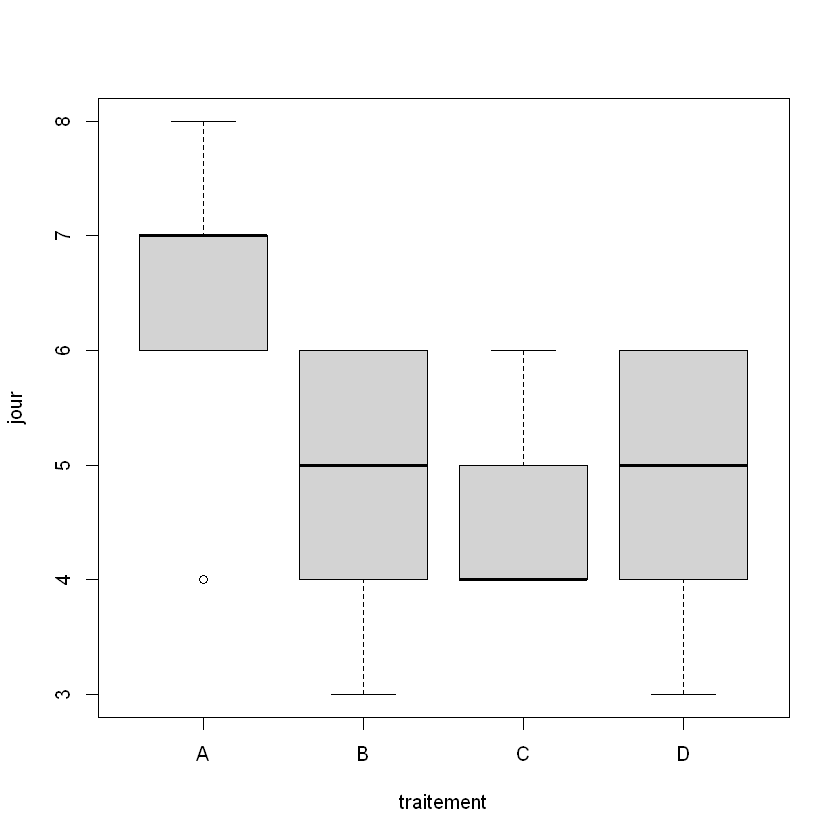

In [10]:
# Afficher un boxplot pour comparer les traitements
boxplot(jour ~ traitement, data = fievre)

**Commentez :**  
On observe que les traitements B, C, D ont tous une médiane inférieure au placebo.
Ils seraient donc plus efficaces que le placebo pour traiter les boutons de fièvres.

#### Hypothèses et réalisation du test de Kruskal-Wallis

Afin de vérifier si il existe une réelle différence significative entre les échantillons, nous allons réaliser un test de Kruskal-Wallis. Rappelez-ci dessous les hypothèses du test de Kruskal-Wallis :


<div class="alert alert-warning" role="alert">

3. **Hypothèses**

H0 : Les moyennes des traitements sont égales

H1 : Au moins un traitement à une moyenne différente des autres

</div>

4. Réalisation du test

Pour réaliser le test de Kruskal-Wallis, il faut utiliser la fonction `kruskal.test()` qui prend comme premier argument `x=`, la variable quantitative que l'on veut comparer, et comme deuxième argument `g=` les groupes que l'on souhaite comparer.

In [11]:
kruskal.test(fievre$jour, fievre$traitement)


	Kruskal-Wallis rank sum test

data:  fievre$jour and fievre$traitement
Kruskal-Wallis chi-squared = 4.9515, df = 3, p-value = 0.1754


**Conclusion** :  
Au seuil alpha = 5%, on observe que p > alpha, donc on accepte H0, ce qui signifie que tous les traitements sont équivalents.

Cela est possible même si on observe visuellement une différence car on a un faible effectif (20 personnes) et que l'on observe de faibles différences entre traitement.


## 2. Test de comparaison non paramétrique de plusieurs échantillons appariés (test de Friedman)

### 2.1 Principe du test 

Il s’agit bien d’un test de comparaison de K moyennes mais sur des données appariées.

<img src="figures/Friedman1.png" />

À la différence du test de Kruskal-Wallis par exemple, les valeurs seront uniquement comparables à l’intérieur de chaque
groupe.

<img src="figures/Friedman2.png" />

Ainsi, nous travaillerons bien sûr des rangs, mais calculés à l’intérieur des blocs, c’est ce qui
différencie le test de Friedman de tous les tests pour échantillons indépendants où les rangs
étaient toujours construits à partir de la totalité des observations mesurées .
Si l’on raisonne par bloc, le principe est le même que celui de Kruskal-Wallis :
- s’il n’existe pas de différence entre les échantillons, la répartition des rangs par bloc entre les échantillons devrait être aléatoire
- ce qui implique que les échantillons devraient avoir approximativement le même rang moyen qui doit correspondre au rang moyen global
- ce qui implique que les différences $\bar{r_k}-\bar{r}$ devrait être proche de 0
- donc si l’on somme ces différences pour tous les échantillons, elle devrait être proche de 0.

### 2.2 Exemple : Méthode pour déterminer le poids d’un comprimé

Trois méthodes différentes de détermination du poids de comprimés sont utilisées. Nous
disposons donc de 10 échantillons (les 10 lots) de taille égale à 1 (1 comprimé par lot) et de 3
méthodes.

Les données sont contenues dans le fichier *`data_poids_comprime.txt`* dans le dossier *`data/`* (chemin d'accès relatif total `data/data_poids_comprime.txt`).

**Les questions sont les suivantes :**
- Les 3 méthodes donnent-elles les mêmes résultats au seuil 5% ?
- Sinon, quelle méthode surestime le poids du comprimé au seuil 5% ?

#### Lecture et description des données

1. Lire les données

In [12]:
comprimes = read.table("data/data_poids_comprime.txt", header = TRUE)

2. Description des données

In [13]:
head(comprimes)
summary(comprimes)

,poids,methode,appariement
,<int>,<chr>,<int>
1,9,methode1,1
2,13,methode1,2
3,12,methode1,3
4,10,methode1,4
5,14,methode1,5
6,11,methode1,6


     poids         methode           appariement  
 Min.   : 6.00   Length:30          Min.   : 1.0  
 1st Qu.: 9.00   Class :character   1st Qu.: 3.0  
 Median :10.00   Mode  :character   Median : 5.5  
 Mean   :10.03                      Mean   : 5.5  
 3rd Qu.:12.00                      3rd Qu.: 8.0  
 Max.   :14.00                      Max.   :10.0  

Vérifiez que les 10 lots ont bien tous été mesurés par les trois méthodes.  
*Indice : comme au-dessus, vous pouvez faire une table de contingence pour le savoir*

In [14]:
# Table de contingence par lot
table(comprimes$lot)

# Table de contingence par méthode
table(comprimes$methode)


 1  2  3  4  5  6  7  8  9 10 
 3  3  3  3  3  3  3  3  3  3 


methode1 methode2 methode3 
      10       10       10 

De manière similaire à l'exemple au-dessus, on va réaliser un *boxplot* du poids du comprimé obtenu en fonction de la méthode.

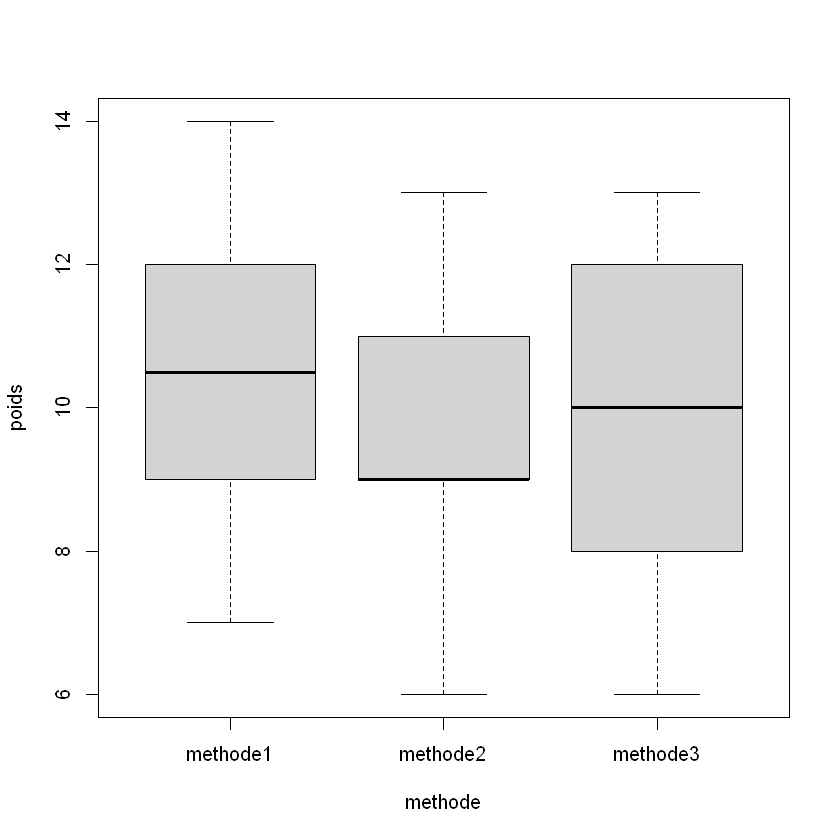

In [15]:
boxplot(poids ~ methode, data = comprimes)

#### Hypothèses et réalisation du test de Friedman

Nous allons maintenant répondre à la première question grâce à un test de Friedman dans la
mesure où les données sont appariées :

<div class="alert alert-warning" role="alert">
    
3. **Hypothèses**

H0 : Il n'y a pas de différence entre les groupes

H1 : Il y a une différence entre les groupes

</div>

4. Réalisation du test

Pour réaliser le test de Friedman, il faut utiliser la fonction **`friedman.test()`** qui prend comme arguments :

1. en premier argument **`y=`**, la variable quantitative à comparer,
2. en deuxième argument **`groups=`**, la variable qui correspond au groupe,
3. et enfin, comme troisième et dernier argument, **`blocks=`**, la variable d'appariement.

Si vous utilisez ces arguments dans l'ordre spécifié au-dessus, il n'est pas nécessaire de leur donner des noms.

In [16]:
friedman.test(comprimes$poids, comprimes$methode, comprimes$lot)


	Friedman rank sum test

data:  comprimes$poids, comprimes$methode and comprimes$appariement
Friedman chi-squared = 6.4118, df = 2, p-value = 0.04052


**Conclusion** :  
Au seuil $\alpha = 5\%$, on observe que p < $\alpha$, donc on rejette H0, ce qui signifie qu'il existe une différence entre les méthodes pour mesurer le poids des comprimés.

Le problème, c'est qu'on ne sait pas quelle méthode surestime le poids du comprimé. Pour ce faire, il est nécessaire de comparer les
résultats des méthodes deux à deux. 

Pour cela, nous allons créer 3 groupes de données :
- un groupe qui contient les poids mesurés par la méthode 1
- un groupe qui contient les poids mesurés par la méthode 2
- un groupe qui contient les poids mesurés par la méthode 3

puis nous comparerons ces groupes deux à deux avec un test non paramétrique de Wilcoxon
pour données appariées :

In [17]:
# Extraction des groupes
methode1 = comprimes[comprimes$methode == "methode1",]
methode2 = comprimes[comprimes$methode == "methode2",]
methode3 = comprimes[comprimes$methode == "methode3",]

# Vérification des groupes
methode1
methode2
methode3

,poids,methode,appariement
,<int>,<chr>,<int>
1,9,methode1,1
2,13,methode1,2
3,12,methode1,3
4,10,methode1,4
5,14,methode1,5
6,11,methode1,6
7,9,methode1,7
8,12,methode1,8
9,9,methode1,9


,poids,methode,appariement
,<int>,<chr>,<int>
11,8,methode2,1
12,13,methode2,2
13,11,methode2,3
14,9,methode2,4
15,12,methode2,5
16,9,methode2,6
17,9,methode2,7
18,11,methode2,8
19,9,methode2,9


,poids,methode,appariement
,<int>,<chr>,<int>
21,10,methode3,1
22,12,methode3,2
23,10,methode3,3
24,8,methode3,4
25,13,methode3,5
26,9,methode3,6
27,8,methode3,7
28,12,methode3,8
29,10,methode3,9


In [18]:
# Comparaison 2 à 2 à partir de test de Wilcoxon
wilcox.test(methode1$poids, methode2$poids, paired = TRUE)
wilcox.test(methode1$poids, methode3$poids, paired = TRUE)
wilcox.test(methode2$poids, methode3$poids, paired = TRUE)

Warning message in wilcox.test.default(methode1$poids, methode2$poids, paired = TRUE):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(methode1$poids, methode2$poids, paired = TRUE):
"impossible de calculer une p-value exacte avec des zéros"



	Wilcoxon signed rank test with continuity correction

data:  methode1$poids and methode2$poids
V = 28, p-value = 0.01766
alternative hypothesis: true location shift is not equal to 0


Warning message in wilcox.test.default(methode1$poids, methode3$poids, paired = TRUE):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(methode1$poids, methode3$poids, paired = TRUE):
"impossible de calculer une p-value exacte avec des zéros"



	Wilcoxon signed rank test with continuity correction

data:  methode1$poids and methode3$poids
V = 38, p-value = 0.0656
alternative hypothesis: true location shift is not equal to 0


Warning message in wilcox.test.default(methode2$poids, methode3$poids, paired = TRUE):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(methode2$poids, methode3$poids, paired = TRUE):
"impossible de calculer une p-value exacte avec des zéros"



	Wilcoxon signed rank test with continuity correction

data:  methode2$poids and methode3$poids
V = 16, p-value = 0.8211
alternative hypothesis: true location shift is not equal to 0


**En conclusion** :  
Au seuil $\alpha = 5\%$, on observe que p < $\alpha$ pour la comparaison entre la méthode 1 et méthode 2 et p > $\alpha$ pour les autres comparaisons. Ce qui signifie que la méthode 1 semble différente des autres, notamment de la méthode 2 pour mesurer le poids des comprimés.

<div class="alert alert-success" role="alert">

## Résumé

* On peut appliquer le test de Kruskal-Wallis de comparaison de moyennes de plusieurs échantillons avec la fonction `kruskal.test()`
* On peut appliquer le test de Friedman de comparaison de moyennes de plusieurs échantillons appariés avec la fonction `friedman.test()`

</div>

## 3. Exercices d'application

### Exercice 3 

Un médicament est administré à un groupe de 12 sujets selon trois modes : dans le mode
I, pris comme référence, le médicament est administré chez les sujets à jeun, dans le mode II
après un petit déjeuner normal et dans le mode III après un petit déjeuner riche en lipides. Les
résultats du dosage sanguin du médicament, notés pour les modes d’administration I, II et III
respectivement y1, y2 et y3 et exprimés en $\text{ng}⋅\text{L}^{-1}$. 

Comparer l’effet sur les taux sanguins du médicament des modes d’administration I, II et III.

Les données sont contenues dans le fichier *`data_exercice3.txt`* dans le dossier *`data/`*.


,sujet,dosage,mode
,<int>,<int>,<chr>
1,1,58,mode1
2,2,82,mode1
3,3,100,mode1
4,4,75,mode1
5,5,88,mode1
6,6,95,mode1



	Friedman rank sum test

data:  exo3$dosage, exo3$mode and exo3$sujet
Friedman chi-squared = 23.532, df = 2, p-value = 7.764e-06


Warning message in wilcox.test.default(mode1$dosage, mode2$dosage, paired = TRUE):
"impossible de calculer la p-value exacte avec des ex-aequos"



	Wilcoxon signed rank test with continuity correction

data:  mode1$dosage and mode2$dosage
V = 0, p-value = 0.002383
alternative hypothesis: true location shift is not equal to 0


Warning message in wilcox.test.default(mode1$dosage, mode3$dosage, paired = TRUE):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(mode1$dosage, mode3$dosage, paired = TRUE):
"impossible de calculer une p-value exacte avec des zéros"



	Wilcoxon signed rank test with continuity correction

data:  mode1$dosage and mode3$dosage
V = 66, p-value = 0.00377
alternative hypothesis: true location shift is not equal to 0


Warning message in wilcox.test.default(mode2$dosage, mode3$dosage, paired = TRUE):
"impossible de calculer la p-value exacte avec des ex-aequos"



	Wilcoxon signed rank test with continuity correction

data:  mode2$dosage and mode3$dosage
V = 78, p-value = 0.002337
alternative hypothesis: true location shift is not equal to 0


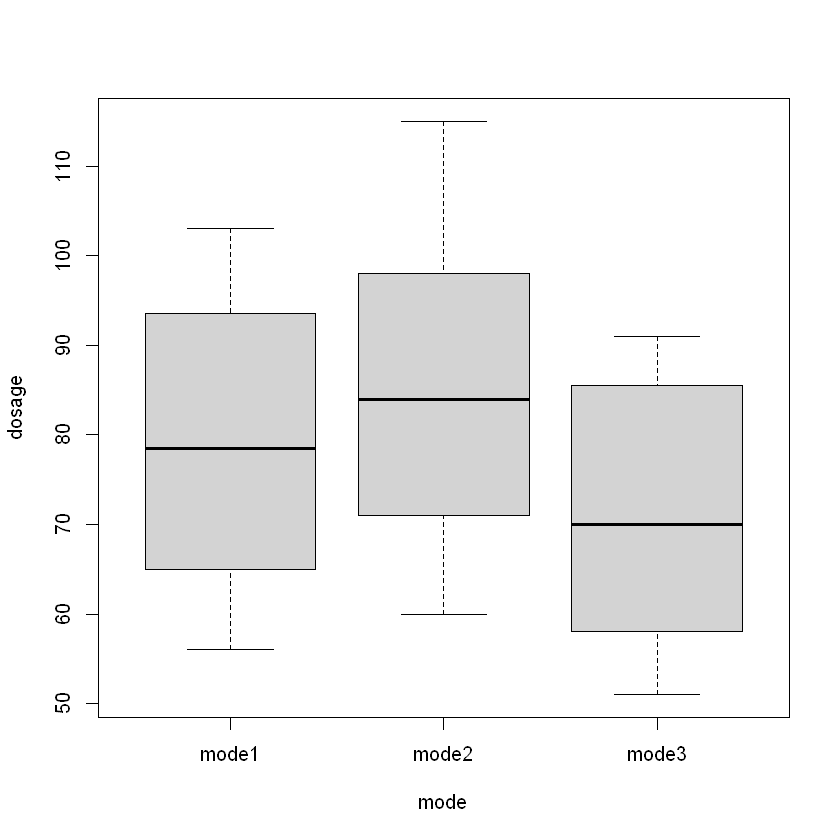

In [19]:
exo3 = read.table("data/data_exercice3.txt", header = TRUE)

# Description des données
head(exo3)

boxplot(dosage ~ mode, data = exo3)

# Hypothèses
# H0 : les trois modes d'administration ne diffèrent pas
# H1 : au moins un mode d'administration diffère des autres

# Réalisation du test
friedman.test(exo3$dosage, exo3$mode, exo3$sujet)

# Conclusion :
# Au seuil alpha = 5%, on a p < alpha, donc on rejette H0,
# ce qui signifie qu'au moins un mode d'administration diffère des autres

# Vérification de quel mode
mode1 = exo3[exo3$mode == "mode1",]
mode2 = exo3[exo3$mode == "mode2",]
mode3 = exo3[exo3$mode == "mode3",]

wilcox.test(mode1$dosage, mode2$dosage, paired = TRUE)
wilcox.test(mode1$dosage, mode3$dosage, paired = TRUE)
wilcox.test(mode2$dosage, mode3$dosage, paired = TRUE)

# Il semble que tous les modes sont différents et donnent trois dosage différents

### Exercice 4

Trois laboratoires différents A, B, C fabriquent des ampoules pour préparations injectables.
On désire savoir si le facteur fabricant a une influence sur les diamètres des ampoules. Les
diamètres de 5 ampoules par fabricant sont mesurés. Les données sont exprimées en mm. 

Répondez aux questions suivantes : 

1. Existe-t-il une différence significative entre les trois ampoules ?
2. Si oui, tester quels laboratoires obtiennent des résultats différents.

Les données sont contenues dans le fichier *`data_exercice4.txt`* dans le dossier *`data/`*.

,diametre,laboratoire
,<dbl>,<chr>
1,10.10,A
2,11.40,A
3,9.85,A
4,11.20,A
5,11.90,A
6,8.70,B


    diametre      laboratoire       
 Min.   : 8.700   Length:15         
 1st Qu.: 9.975   Class :character  
 Median :11.200   Mode  :character  
 Mean   :10.887                     
 3rd Qu.:11.750                     
 Max.   :12.700                     

[1] 15


A B C 
5 5 5 


	Kruskal-Wallis rank sum test

data:  exo4$diametre and exo4$laboratoire
Kruskal-Wallis chi-squared = 7.4818, df = 2, p-value = 0.02373


...


	Wilcoxon rank sum test with continuity correction

data:  labA$diametre and labB$diametre
W = 20.5, p-value = 0.1161
alternative hypothesis: true location shift is not equal to 0


Warning message in wilcox.test.default(labA$diametre, labC$diametre):
"impossible de calculer la p-value exacte avec des ex-aequos"



	Wilcoxon rank sum test with continuity correction

data:  labA$diametre and labC$diametre
W = 5, p-value = 0.1388
alternative hypothesis: true location shift is not equal to 0


Warning message in wilcox.test.default(labB$diametre, labC$diametre):
"impossible de calculer la p-value exacte avec des ex-aequos"



	Wilcoxon rank sum test with continuity correction

data:  labB$diametre and labC$diametre
W = 1, p-value = 0.02118
alternative hypothesis: true location shift is not equal to 0


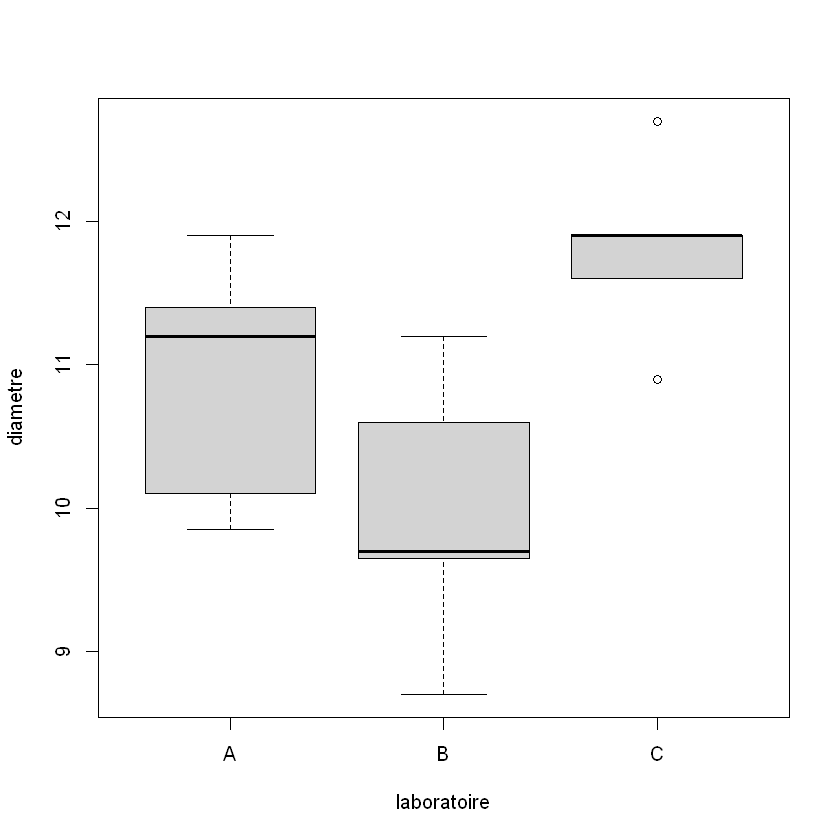

In [20]:
exo4 = read.table("data/data_exercice4.txt", header = TRUE)
head(exo4)

# Description des données
summary(exo4)
length(exo4$diametre)
table(exo4$laboratoire)

boxplot(diametre ~ laboratoire, data = exo4)

## Question 1
# Il semblerait que le laboratoire C mesure plus souvent des diamètres importants,
# le laboratoire B des diamètres faibles, et le laboratoire

# Hypothèses
# H0 : Les mesures entre les laboratoires sont identiques
# H1 : Les mesures d'au moins un laboratoire sont différentes des autres

# Réalisation du test
kruskal.test(exo4$diametre, exo4$laboratoire)

# Conclusion
# Au seuil alpha = 5%, on a p = 2,4% < alpha, donc on rejette H0
# Ce qui signifie qu'au moins un laboratoire fabrique des ampoules de diamètre différent

## Question 2
labA = exo4[exo4$laboratoire == "A",]
labB = exo4[exo4$laboratoire == "B",]
labC = exo4[exo4$laboratoire == "C",]

wilcox.test(labA$diametre, labB$diametre)
wilcox.test(labA$diametre, labC$diametre)
wilcox.test(labB$diametre, labC$diametre)

# Le labo B semble produire des ampoules plus petites que le labo C